In [243]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [244]:
dt = pd.read_csv("kidney_disease (1).csv")
dt.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [245]:
dt.info()  # insight some are float and some are integer and some of the values are interger

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [246]:
dt.shape # insight 400 -> rows and 26 -> columns

(400, 26)

In [247]:
dt.columns 

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [248]:
dt.drop("id",axis=1,inplace=True)

In [249]:
dt.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [250]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             330 non-null    object 
 16  wc              295 non-null    object 
 17  rc              270 non-null    obj

In [251]:
dt.pcv.unique()  # due some string value in columns it is string

array(['44', '38', '31', '32', '35', '39', '36', '33', '29', '28', nan,
       '16', '24', '37', '30', '34', '40', '45', '27', '48', '\t?', '52',
       '14', '22', '18', '42', '17', '46', '23', '19', '25', '41', '26',
       '15', '21', '43', '20', '\t43', '47', '9', '49', '50', '53', '51',
       '54'], dtype=object)

In [252]:
dt.pcv = pd.to_numeric(dt["pcv"],errors="coerce") # coerce means to ignore the error

In [253]:
dt.pcv.dtype

dtype('float64')

In [254]:
dt.pcv.unique()

# in this all the string values will be converted into nan values 

array([44., 38., 31., 32., 35., 39., 36., 33., 29., 28., nan, 16., 24.,
       37., 30., 34., 40., 45., 27., 48., 52., 14., 22., 18., 42., 17.,
       46., 23., 19., 25., 41., 26., 15., 21., 43., 20., 47.,  9., 49.,
       50., 53., 51., 54.])

In [255]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             329 non-null    float64
 16  wc              295 non-null    object 
 17  rc              270 non-null    obj

In [256]:
dt.wc.unique()

array(['7800', '6000', '7500', '6700', '7300', nan, '6900', '9600',
       '12100', '4500', '12200', '11000', '3800', '11400', '5300', '9200',
       '6200', '8300', '8400', '10300', '9800', '9100', '7900', '6400',
       '8600', '18900', '21600', '4300', '8500', '11300', '7200', '7700',
       '14600', '6300', '\t6200', '7100', '11800', '9400', '5500', '5800',
       '13200', '12500', '5600', '7000', '11900', '10400', '10700',
       '12700', '6800', '6500', '13600', '10200', '9000', '14900', '8200',
       '15200', '5000', '16300', '12400', '\t8400', '10500', '4200',
       '4700', '10900', '8100', '9500', '2200', '12800', '11200', '19100',
       '\t?', '12300', '16700', '2600', '26400', '8800', '7400', '4900',
       '8000', '12000', '15700', '4100', '5700', '11500', '5400', '10800',
       '9900', '5200', '5900', '9300', '9700', '5100', '6600'],
      dtype=object)

In [257]:
dt.wc = pd.to_numeric(dt["wc"],errors="coerce")

In [258]:
dt.rc = pd.to_numeric(dt["rc"],errors="coerce")

In [259]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             329 non-null    float64
 16  wc              294 non-null    float64
 17  rc              269 non-null    flo

In [260]:
dt.shape

(400, 25)

In [261]:
obj_col = [i for i in dt.columns if dt[i].dtype == "object"]

In [262]:
num_col = [i for i in dt.columns if dt[i].dtype != "object"]

In [263]:
for col in obj_col:
    print(f"{col} has {dt[col].unique()}")

rbc has [nan 'normal' 'abnormal']
pc has ['normal' 'abnormal' nan]
pcc has ['notpresent' 'present' nan]
ba has ['notpresent' 'present' nan]
htn has ['yes' 'no' nan]
dm has ['yes' 'no' ' yes' '\tno' '\tyes' nan]
cad has ['no' 'yes' '\tno' nan]
appet has ['good' 'poor' nan]
pe has ['no' 'yes' nan]
ane has ['no' 'yes' nan]
classification has ['ckd' 'ckd\t' 'notckd']


In [264]:
dt.dm.replace(to_replace={" yes":"yes","\tno":"no","\tyes":"yes"},inplace=True)

In [265]:
dt.dm.unique()

array(['yes', 'no', nan], dtype=object)

In [266]:
dt.cad.replace(to_replace="\tno",value="no").unique()

array(['no', 'yes', nan], dtype=object)

In [267]:
dt.classification = dt.classification.map({"ckd":1,"ckd\t":0,"notckd":1})

In [268]:
for col in obj_col:
    print(f"{col} has {dt[col].unique()}")


rbc has [nan 'normal' 'abnormal']
pc has ['normal' 'abnormal' nan]
pcc has ['notpresent' 'present' nan]
ba has ['notpresent' 'present' nan]
htn has ['yes' 'no' nan]
dm has ['yes' 'no' nan]
cad has ['no' 'yes' '\tno' nan]
appet has ['good' 'poor' nan]
pe has ['no' 'yes' nan]
ane has ['no' 'yes' nan]
classification has [1 0]


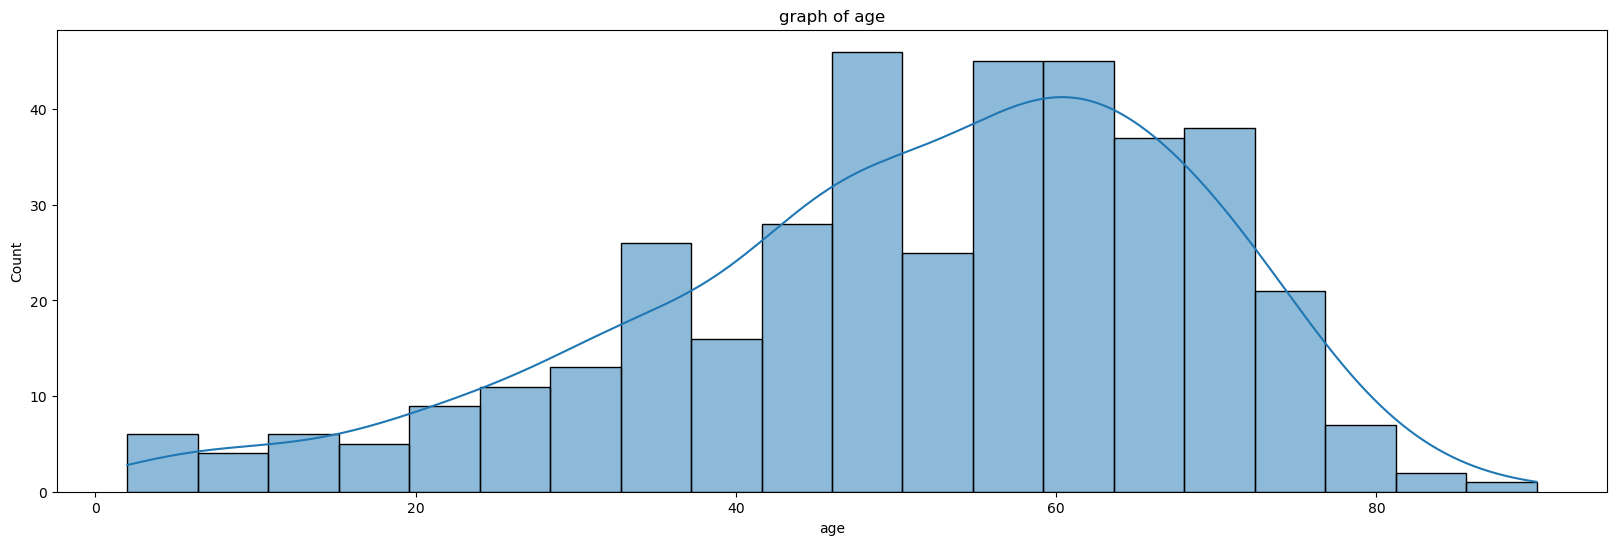

In [269]:
# univariate analysis
plt.figure(figsize=(20,6))
sns.histplot(dt["age"].dropna(),kde=True,bins=20)
plt.title("graph of age")
plt.show()

In [270]:
dt.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

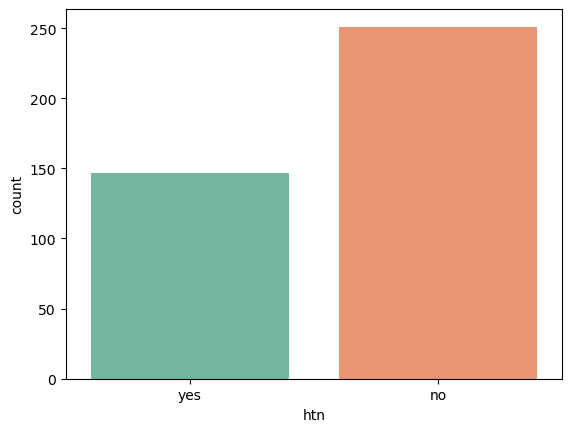

In [271]:
sns.countplot(x="htn",data=dt,palette="Set2")
plt.show()

<Axes: xlabel='classification', ylabel='bu'>

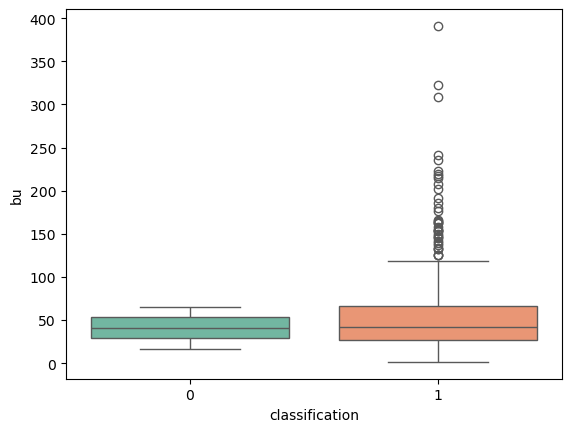

In [272]:
sns.boxplot(x="classification",y="bu",data = dt ,palette="Set2")

<Axes: xlabel='ane', ylabel='count'>

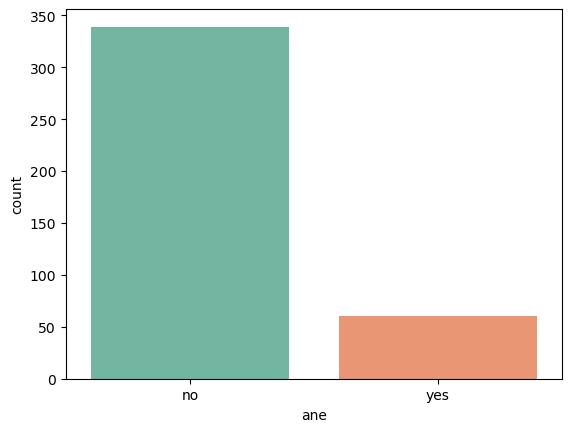

In [273]:
sns.countplot(x="ane",data=dt,palette="Set2") # majority of people not suffering from anemia

<Axes: ylabel='count'>

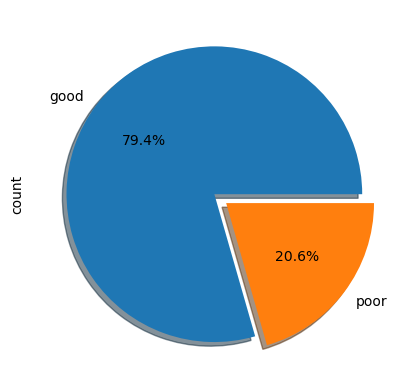

In [274]:
dt.appet.value_counts().plot.pie(autopct="%1.1f%%",explode=(0,0.1),shadow=True)


<Axes: xlabel='wc', ylabel='Count'>

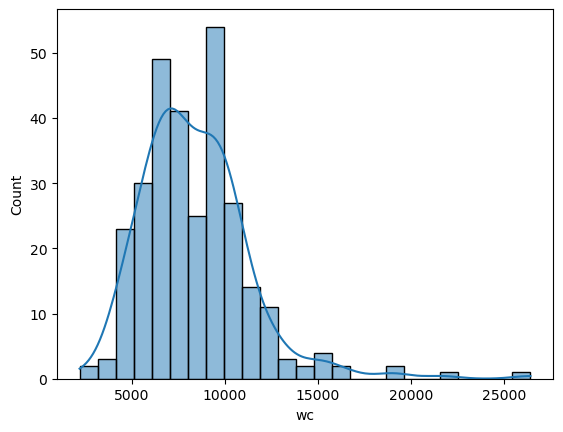

In [275]:
sns.histplot(x=dt["wc"].dropna(),kde=True)

In [276]:
dt.cad.replace(to_replace="\tno",value="no",inplace=True)

In [277]:
dt.cad.value_counts()

cad
no     364
yes     34
Name: count, dtype: int64

<Axes: xlabel='cad', ylabel='count'>

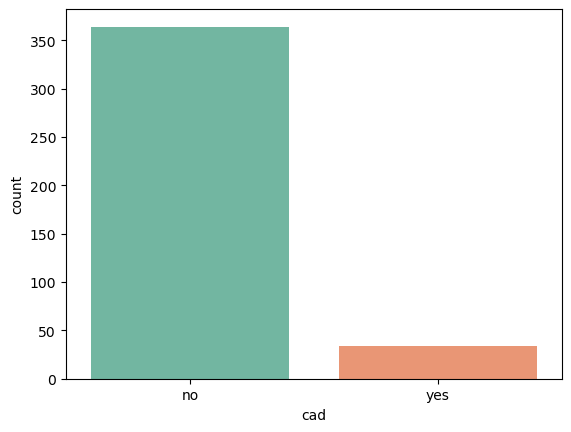

In [278]:
sns.countplot(x="cad",data=dt,palette="Set2")

In [279]:
dt.pe.value_counts()

pe
no     323
yes     76
Name: count, dtype: int64

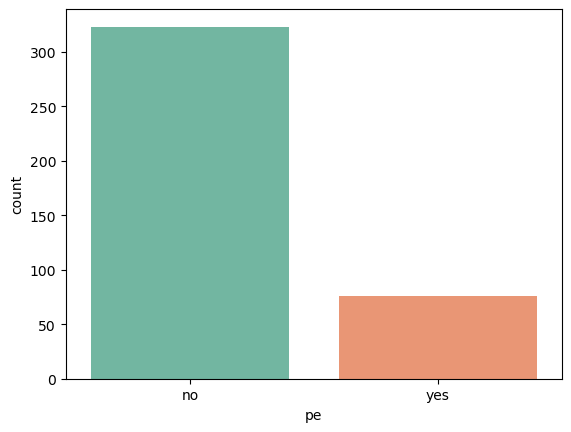

In [281]:
sns.countplot(x="pe",data=dt,palette="Set2")
plt.show()

In [282]:
dt.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

<Axes: xlabel='age', ylabel='bp'>

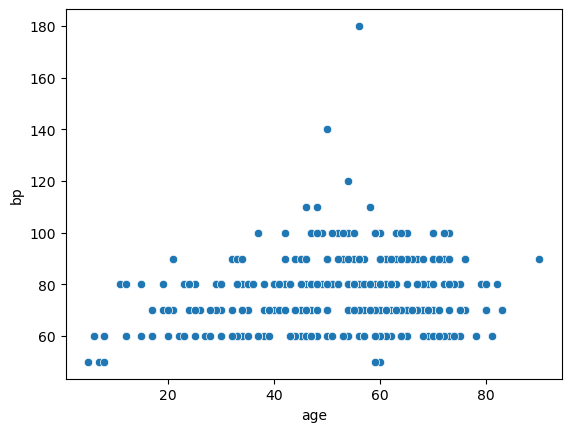

In [284]:
# bivariate analysis 
sns.scatterplot(x="age",y = "bp",data=dt)